# Preprocessing & Feature Extraction

We turn raw wrist signals into the tensor ``X (N, 12, F)`` that the LSTM consumes.

Main pipeline : **filter -> segment 60 s windows (stride 15 s) -> split each window into 12×5 s sub-windows -> extract HRV / EDA / TEMP / ACC features per sub-window**.

Frequency-domain HRV (LF / HF / LF-HF) is computed once per 60 s window and broadcast to all sub-windows because 5 s is too short for a reliable LF estimate.

In [1]:
import sys, pathlib, importlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

# Force-reload
import src.preprocessing, src.features, src.windowing
for _mod in [src.preprocessing, src.features, src.windowing]:
    importlib.reload(_mod)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk

from src.config import WRIST_FS, LABEL_NAMES, PROCESSED_DIR
from src.wesad_loader import load_subject
from src.preprocessing import (
    filter_bvp, filter_eda, filter_temp, acc_magnitude, filter_acc_mag,
)
from src.features import SUBWINDOW_FEATURE_NAMES
from src.windowing import windows_from_subject, build_dataset

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
rec = load_subject('S2')


## Raw vs band-passed BVP

Text(0.5, 1.0, 'BVP filtering (10 s)')

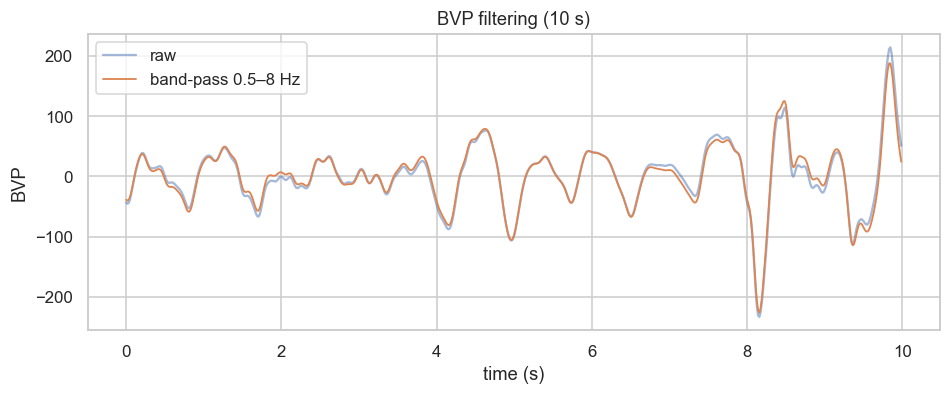

In [2]:
fs = WRIST_FS['BVP']
start = 60 * fs   # skip the first minute (sensor settling)
raw = rec.bvp[start:start + 10 * fs]
filt = filter_bvp(rec.bvp, fs)[start:start + 10 * fs]
t = np.arange(len(raw)) / fs

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(t, raw, label='raw', alpha=0.5)
ax.plot(t, filt, label='band-pass 0.5–8 Hz', lw=1.2)
ax.set_xlabel('time (s)'); ax.set_ylabel('BVP'); ax.legend()
ax.set_title('BVP filtering (10 s)')

## PPG peak detection + RR-interval tachogram

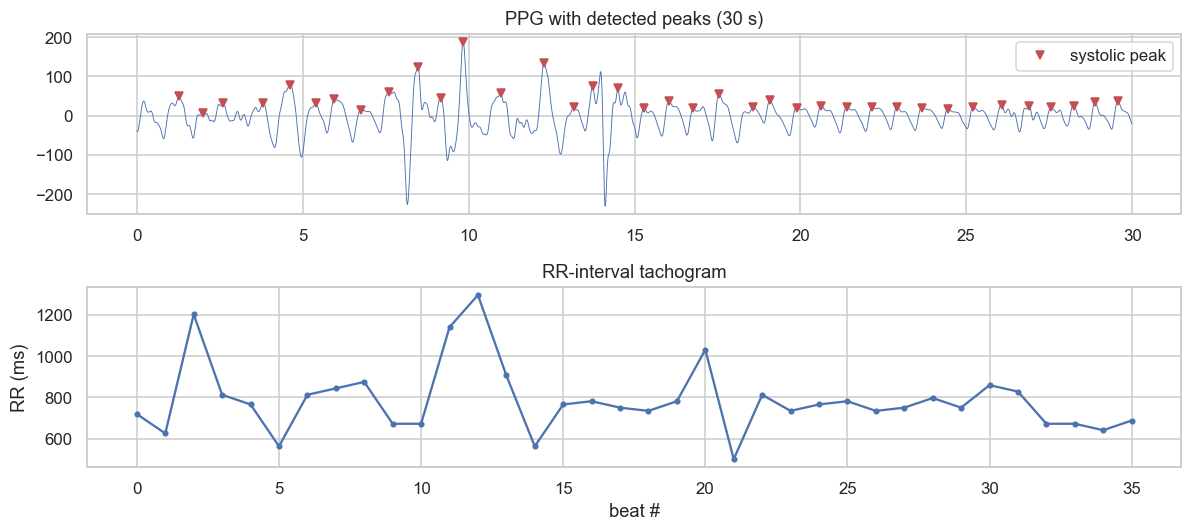

In [3]:
seg = filter_bvp(rec.bvp, fs)[60 * fs:60 * fs + 30 * fs]
peaks = nk.ppg_findpeaks(seg, sampling_rate=fs, show=False)['PPG_Peaks']
rri_ms = np.diff(peaks) / fs * 1000.0

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=False)
axes[0].plot(np.arange(len(seg)) / fs, seg, lw=0.6)
axes[0].plot(peaks / fs, seg[peaks], 'rv', ms=5, label='systolic peak')
axes[0].set_title('PPG with detected peaks (30 s)'); axes[0].legend()
axes[1].plot(np.arange(len(rri_ms)), rri_ms, '-o', ms=3)
axes[1].set_title('RR-interval tachogram'); axes[1].set_xlabel('beat #'); axes[1].set_ylabel('RR (ms)')
fig.tight_layout()

## EDA decomposition (tonic SCL + phasic SCR + peaks)

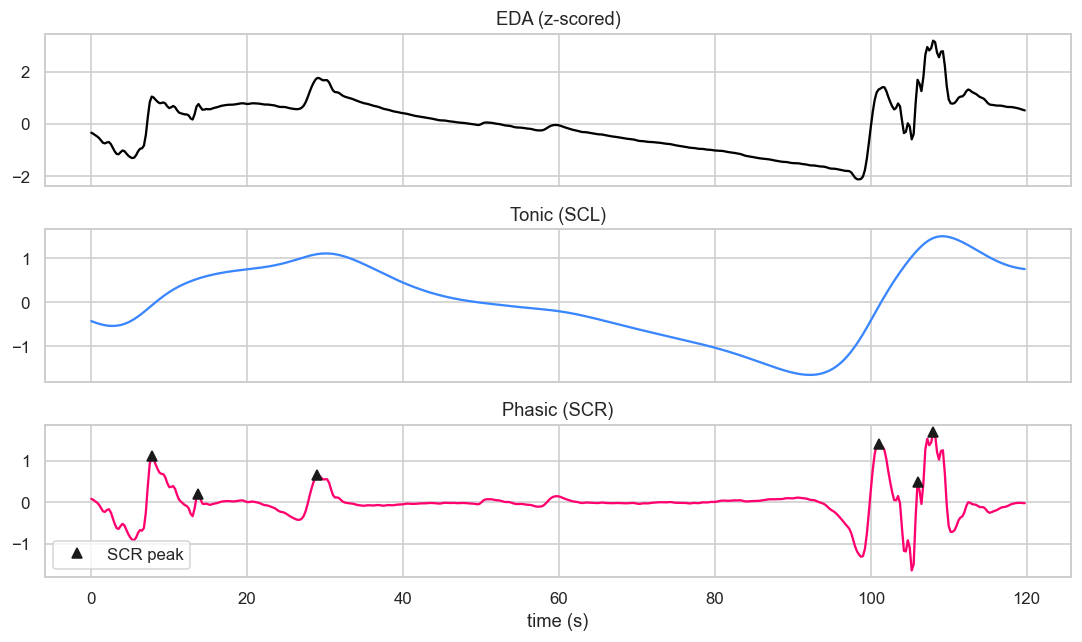

In [4]:
fs_eda = WRIST_FS['EDA']
eda_seg = filter_eda(rec.eda, fs_eda)[60 * fs_eda: 60 * fs_eda + 120 * fs_eda]
decomp = nk.eda_phasic(nk.standardize(eda_seg), sampling_rate=fs_eda, method='highpass')
_, info = nk.eda_peaks(decomp['EDA_Phasic'].to_numpy(), sampling_rate=fs_eda, method='neurokit')
peaks = info.get('SCR_Peaks', np.array([]))

t = np.arange(len(eda_seg)) / fs_eda
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t, nk.standardize(eda_seg), color='black'); axes[0].set_title('EDA (z-scored)')
axes[1].plot(t, decomp['EDA_Tonic'], color='#3a86ff'); axes[1].set_title('Tonic (SCL)')
axes[2].plot(t, decomp['EDA_Phasic'], color='#ff006e'); axes[2].set_title('Phasic (SCR)')
if len(peaks):
    axes[2].plot(np.asarray(peaks) / fs_eda, decomp['EDA_Phasic'].to_numpy()[peaks],
                 'k^', ms=6, label='SCR peak')
    axes[2].legend()
axes[-1].set_xlabel('time (s)')
fig.tight_layout()

## TEMP raw vs median-filtered with linear trend

Text(0.5, 1.0, 'Wrist temperature — full session')

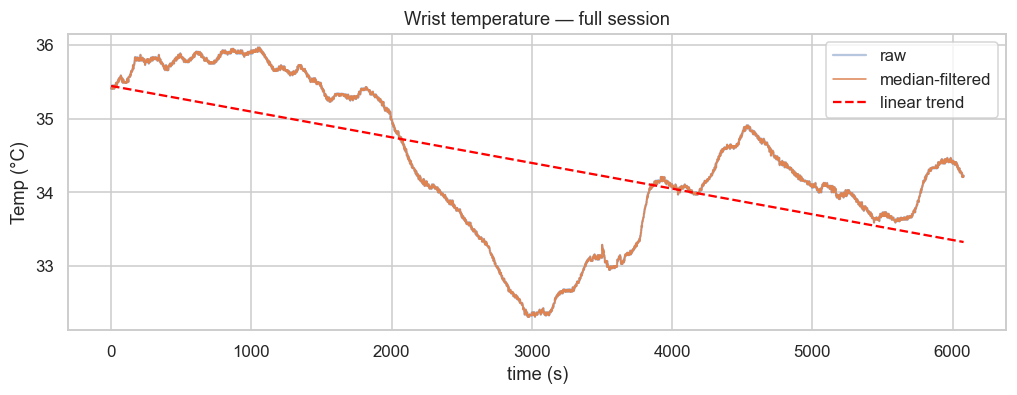

In [5]:
raw_temp = rec.temp
filt_temp = filter_temp(raw_temp)
trend = np.poly1d(np.polyfit(np.arange(len(filt_temp)), filt_temp, 1))(np.arange(len(filt_temp)))
fs_t = WRIST_FS['TEMP']
t = np.arange(len(raw_temp)) / fs_t
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t, raw_temp, alpha=0.4, label='raw')
ax.plot(t, filt_temp, lw=1, label='median-filtered')
ax.plot(t, trend, '--', color='red', label='linear trend')
ax.set_xlabel('time (s)'); ax.set_ylabel('Temp (°C)'); ax.legend()
ax.set_title('Wrist temperature — full session')

## ACC tri-axial + magnitude (band-passed)

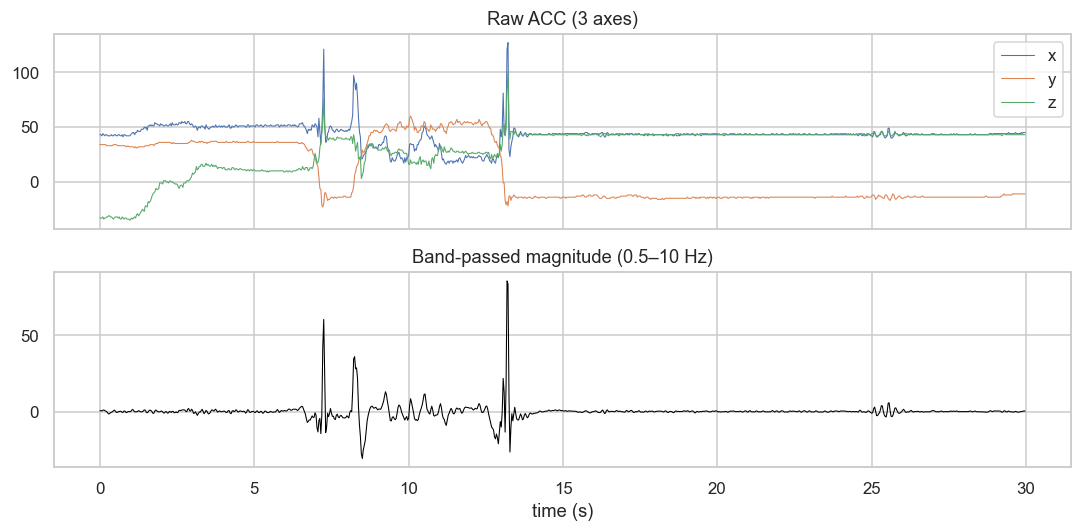

In [6]:
fs_a = WRIST_FS['ACC']
a = 60 * fs_a; b = a + 30 * fs_a
acc_xyz = rec.acc[a:b]
acc_mag = filter_acc_mag(acc_magnitude(rec.acc), fs_a)[a:b]
t = np.arange(b - a) / fs_a
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for i, axis in enumerate(['x', 'y', 'z']):
    axes[0].plot(t, acc_xyz[:, i], lw=0.7, label=axis)
axes[0].set_title('Raw ACC (3 axes)'); axes[0].legend()
axes[1].plot(t, acc_mag, color='black', lw=0.7)
axes[1].set_title('Band-passed magnitude (0.5–10 Hz)'); axes[1].set_xlabel('time (s)')
fig.tight_layout()

## Run the windowing pipeline on a couple of subjects

In [7]:
rec_a = load_subject('S2')
rec_b = load_subject('S5')
X_a, y_a = windows_from_subject(rec_a)
X_b, y_b = windows_from_subject(rec_b)
X = np.concatenate([X_a, X_b]); y = np.concatenate([y_a, y_b])
print('X shape:', X.shape, '| y shape:', y.shape)
print('Class counts:', dict(zip(*np.unique(y, return_counts=True))))
print('Feature names (', len(SUBWINDOW_FEATURE_NAMES), '):')
print(SUBWINDOW_FEATURE_NAMES)

X shape: (226, 12, 23) | y shape: (226,)
Class counts: {np.int64(0): np.int64(149), np.int64(1): np.int64(77)}
Feature names ( 23 ):
['hrv_meanNN', 'hrv_SDNN', 'hrv_RMSSD', 'hrv_pNN50', 'hrv_LF', 'hrv_HF', 'hrv_LFHF', 'eda_scl_mean', 'eda_scl_slope', 'eda_scr_mean', 'eda_scr_std', 'eda_scr_auc', 'eda_scr_peaks', 'eda_scr_amp_mean', 'temp_mean', 'temp_std', 'temp_slope', 'temp_min', 'temp_max', 'acc_mag_mean', 'acc_mag_std', 'acc_mag_energy', 'acc_mag_zcr']


## Feature distributions per class
We average each feature across the 12 sub-windows of every window, then violin-plot per class. A clearly separated feature is informative.

C:\Users\daniion6\AppData\Local\Temp\ipykernel_36752\1521859574.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=long, x='class', y='value', col='feature', kind='violin',


Text(0.5, 1.02, 'Per-class feature distributions (S2 + S5)')

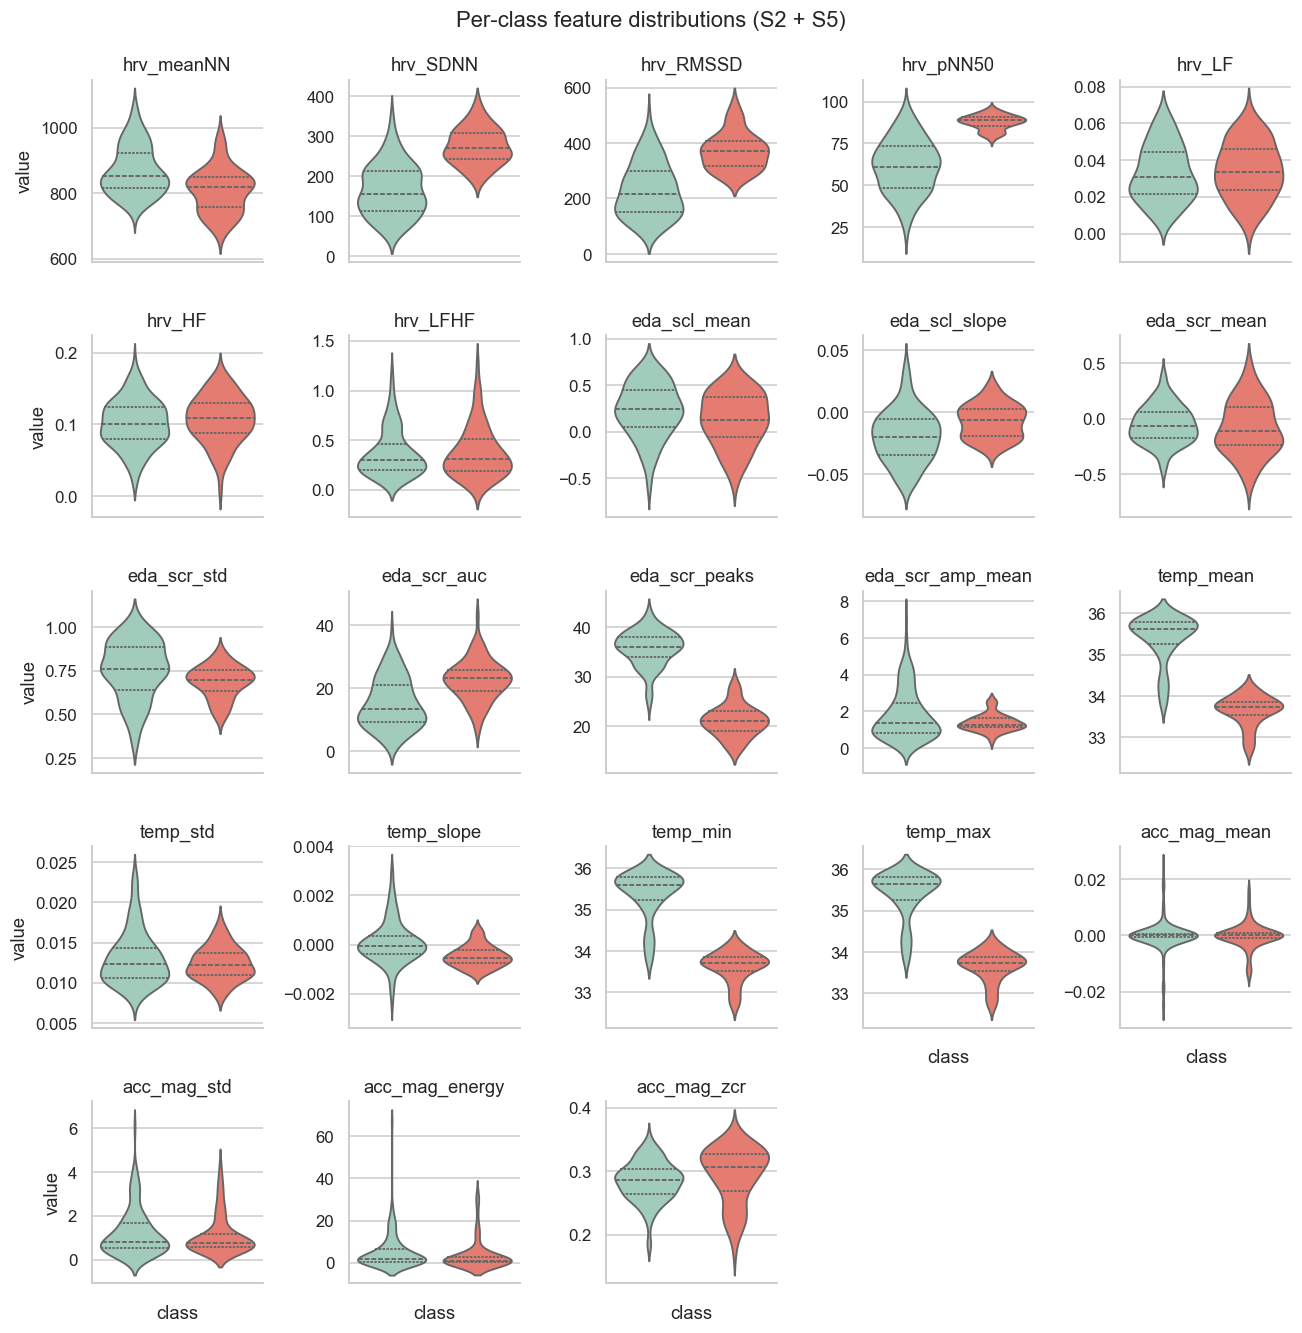

In [8]:
Xm = X.mean(axis=1)  # (N, F)
df = pd.DataFrame(Xm, columns=SUBWINDOW_FEATURE_NAMES)
df['class'] = [LABEL_NAMES[int(c)] for c in y]
long = df.melt(id_vars='class', var_name='feature', value_name='value')

g = sns.catplot(data=long, x='class', y='value', col='feature', kind='violin',
                col_wrap=5, sharey=False, height=2.4, inner='quartile',
                palette={'normal': '#9ad3bc', 'stress': '#f76c5e'})
g.set_titles(col_template='{col_name}')
g.set_xticklabels(rotation=20)
g.fig.suptitle('Per-class feature distributions (S2 + S5)', y=1.02)


## Feature correlation heatmap

Text(0.5, 1.0, 'Feature correlation (Pearson)')

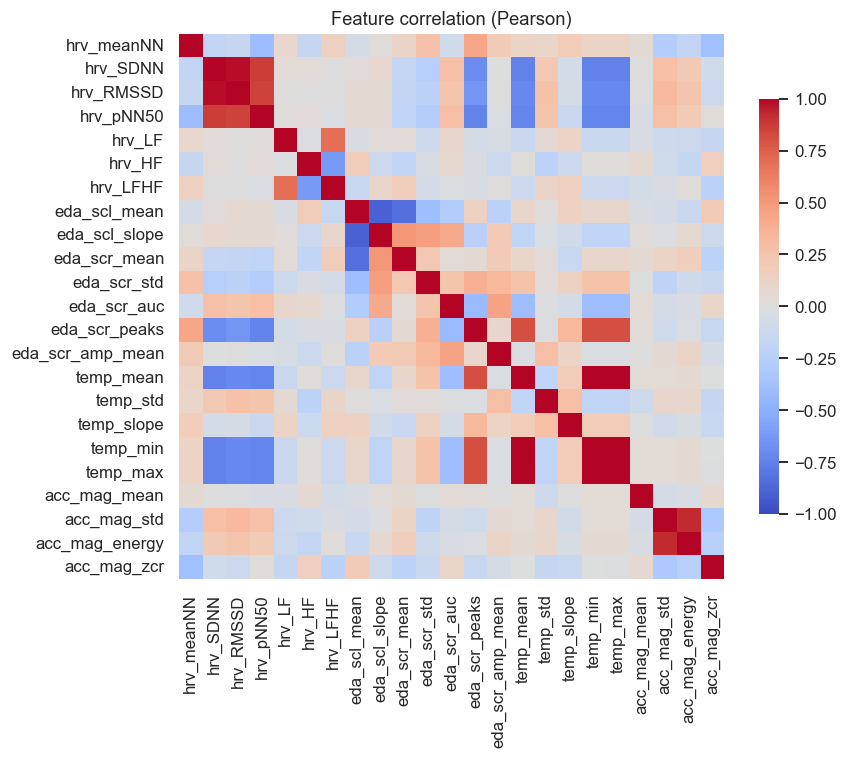

In [9]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(df.drop(columns='class').corr(), cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, square=True, cbar_kws={'shrink': 0.7})
ax.set_title('Feature correlation (Pearson)')

## 2-D PCA of feature vectors

Text(0.5, 1.0, 'PCA of per-window features (S2 + S5)')

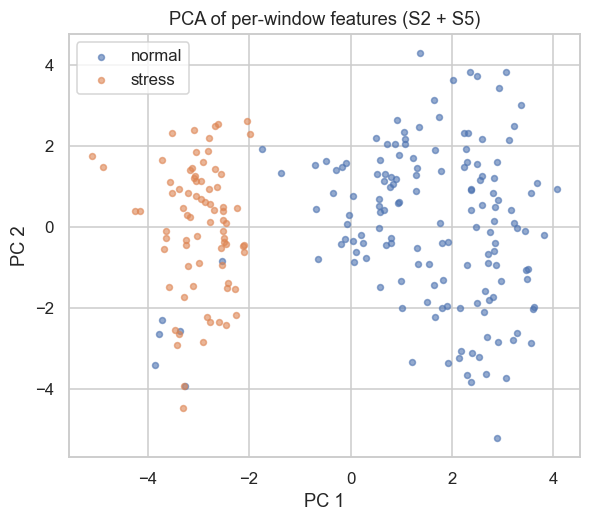

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
Z = StandardScaler().fit_transform(np.nan_to_num(Xm))
pcs = PCA(n_components=2).fit_transform(Z)
fig, ax = plt.subplots(figsize=(6, 5))
for c in np.unique(y):
    m = y == c
    ax.scatter(pcs[m, 0], pcs[m, 1], s=15, alpha=0.6, label=LABEL_NAMES[int(c)])
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2'); ax.legend()
ax.set_title('PCA of per-window features (S2 + S5)')

## Build the full dataset
The result is cached at ``ml/data/processed/wesad_wrist.npz`` and reused by notebook 03.

In [11]:
summary = build_dataset(out_path=PROCESSED_DIR / 'wesad_wrist.npz')
summary

Subjects: 15it [03:28, 13.87s/it]


{'out_path': 'C:\\Users\\daniion6\\AndroidStudioProjects\\MindWave\\ml\\data\\processed\\wesad_wrist.npz',
 'X_shape': (1738, 12, 23),
 'y_shape': (1738,),
 'n_subjects': 15,
 'class_counts': {0: 1124, 1: 614}}